<html> <h1 style="font-style:bold; color:blue;"> Neural Computing and Deep Learning </h1> </html>

<html> <h1 style="font-style:italic; color:blue;"> Week-10 </h1> </html>

<html> <h2 style="font-style:italic; color:blue;"> Simple AutoEncoders with Image Data </h2> </html>

Here is a simple autoencoder with just the dense layers.


Load the data and import the libraries.

In [1]:
# Your code to import matplotlib, pandas and numpy libraries

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

_______________________![image.png](attachment:a4e07154-e766-4e74-a203-c09e7605ea7b.png)

In [2]:
import tensorflow as tf
from tensorflow import keras

In [3]:
print(tf.__version__)

2.21.0


__________________![image.png](attachment:06d151d2-f461-411d-8325-a4a6287cfd48.png)

____________________![image.png](attachment:3ff556fc-1f76-4be4-a216-1e8aecd11e54.png)

In [4]:
from keras.layers import Input, Dense
from keras.models import Model

from keras.datasets import mnist

In [5]:
# Your code to load MNIST data and store it in variables x_train, x_test.
# Note -  we do not need labels as it's autoencoder.

#

(x_train, _), (x_test, _) = mnist.load_data()

______________________![image.png](attachment:74823cdf-09eb-4a7a-8a39-8c306d6de031.png)

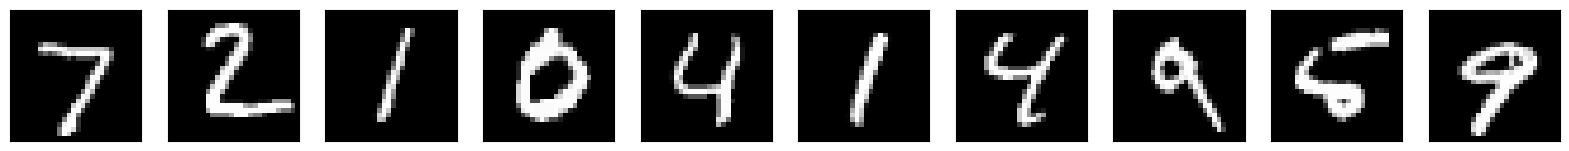

In [6]:

n = 10
plt.figure(figsize=(20, 4))
for i in range(n):

    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.show()

In [7]:
# Normalize train data - Divided by 255
x_train = x_train.astype("float32") / 255.0

# Normalize test data - Divided by 255
x_test = x_test.astype("float32") / 255.0


In [8]:
from tensorflow.keras.layers import GaussianNoise

<html> <h3 style="font-style:italic; color:blue;"> Basic AutoEncoder : </h3> </html>

Build a basic symmetric encoder-decoder network that recreates the image.  
This network could be used in dimensionaliry reduction or feature learning.


________________________![image.png](attachment:de80ae8e-d8d5-4cfc-a51b-a2f7d50dc7c2.png)

In [9]:
from tensorflow.keras.layers import GaussianNoise
import numpy as np

noisy_sample = GaussianNoise(0.2)
print(noisy_sample(x_test[0:2], training=True))

tf.Tensor(
[[[ 0.13710625  0.01264999  0.01730377 ...  0.16801113  0.26532584
    0.46297327]
  [-0.21293731 -0.4324254  -0.24997376 ... -0.10843439 -0.16584782
    0.03193512]
  [ 0.07221614  0.18843418  0.38277075 ...  0.02367702 -0.0933709
    0.17926177]
  ...
  [ 0.16080315  0.15671894 -0.14737219 ...  0.19631231  0.11194333
    0.14509805]
  [ 0.14439298  0.10257345  0.32933387 ... -0.25883815 -0.09652798
   -0.27916273]
  [-0.32502767  0.00454912 -0.0440139  ...  0.0659912   0.20888244
    0.05441705]]

 [[ 0.01286461 -0.09059508  0.27638003 ... -0.02697193  0.1382779
   -0.16585444]
  [ 0.3103287  -0.00054856  0.37342378 ... -0.24829236 -0.14027227
    0.00340522]
  [-0.31550154 -0.1733931   0.09977117 ... -0.1068723  -0.15367243
    0.20678146]
  ...
  [ 0.23319955  0.47487566 -0.1747057  ...  0.17971891  0.07038169
    0.04340851]
  [-0.12620956 -0.00386919  0.295729   ...  0.01248941 -0.09973291
    0.1686417 ]
  [-0.10362873  0.21071659  0.520616   ...  0.24704824  0.011482

Image size: 784


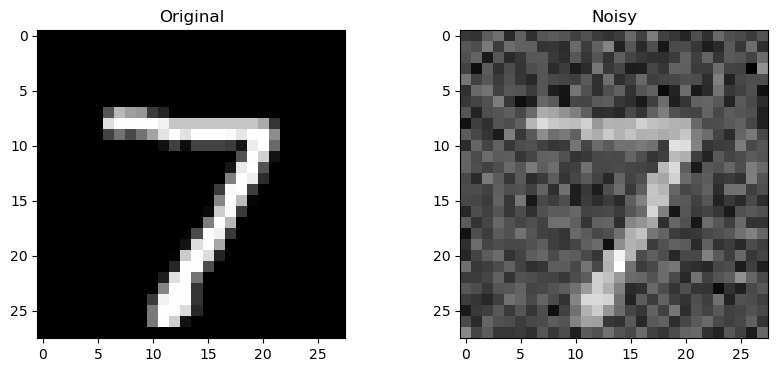

In [10]:
print("Image size:", x_test[0].size)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(x_test[0], cmap='gray')
plt.title("Original")

plt.subplot(1, 2, 2)
plt.imshow(GaussianNoise(0.2)(x_test[0:1], training=True)[0], cmap='gray')
plt.title("Noisy")
plt.show()

In [17]:
from keras.models import Sequential
from keras.layers import Flatten, Dense
from tensorflow.keras.layers import GaussianNoise

encoder = Sequential()
encoder.add(Flatten(input_shape=[28, 28]))
encoder.add(GaussianNoise(0.2))
encoder.add(Dense(512, activation='relu'))
encoder.add(Dense(256, activation='relu'))
encoder.add(Dense(150, activation='relu'))
encoder.add(Dense(75,  activation='relu'))
encoder.add(Dense(25,  activation='relu'))
print(encoder.summary())

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gaussian_noise_4                │ (None, 784)            │             0 │
│ (GaussianNoise)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 150)            │        38,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 75)             │        11,325 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 25)             │         1,900 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 585,023 (2.23 MB)

 Trainable params: 585,023 (2.23 MB)

 Non-trainable params: 0 (0.00 B)

None


In [18]:
from keras.models import Sequential
from keras.layers import Dense, Reshape

decoder = Sequential()
decoder.add(Dense(75,  input_shape=[25], activation='relu'))
decoder.add(Dense(150, activation='relu'))
decoder.add(Dense(256, activation='relu'))
decoder.add(Dense(512, activation='relu'))
decoder.add(Dense(28 * 28, activation='sigmoid'))
decoder.add(Reshape([28, 28]))
print(decoder.summary())

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_25 (Dense)                │ (None, 75)             │         1,950 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 150)            │        11,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 256)            │        38,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 784)            │       402,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_2 (Reshape)             │ (None, 28, 28)         │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 585,782 (2.23 MB)

 Trainable params: 585,782 (2.23 MB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
# Your code to print your Encoder model

#


In [ ]:
# Your OWN Encoder model should be printed here
# Please do not copy the model below

In [19]:
# Your code to print the Decoder model

noise_remover = Sequential([encoder, decoder])
print(noise_remover.summary())


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_6 (Sequential)       │ (None, 25)             │       585,023 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_7 (Sequential)       │ (None, 28, 28)         │       585,782 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,170,805 (4.47 MB)

 Trainable params: 1,170,805 (4.47 MB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
# Your OWN Decoder model should be printed here
# Please do not copy the model below

____________________![image.png](attachment:a94c2e5b-e27d-4e12-84c9-116a2f70e393.png)

In [20]:
noise_remover.compile(optimizer='adam',
                      loss='binary_crossentropy',
                      metrics=['accuracy'])

In [ ]:
# Your code to print the Autoencoder model

#

In [ ]:
# Your OWN Autoencoder model should be printed here

In [ ]:
#SGD?

In [ ]:
# Your code to compile the Autoencoder.
# Use binary_crossenropy as loss and metrics as accuracy.

#


<html> <h3 style="font-style:italic; color:red;"> If you are using a personal laptop without a GPU, change the number of epochs to 10:  

epochs=10 </h3> </html>

___________________![image.png](attachment:c8684fc7-fcb0-48bf-87e8-f70857a0fc4e.png)

In [21]:
history_2 = noise_remover.fit(x=x_train, y=x_train,
                               epochs=10,
                               batch_size=128,
                               shuffle=True,
                               verbose=1,
                               validation_data=(x_test, x_test))

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 35s 57ms/step - accuracy: 0.1556 - loss: 0.1978 - val_accuracy: 0.2132 - val_loss: 0.1433
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 44s 63ms/step - accuracy: 0.2227 - loss: 0.1335 - val_accuracy: 0.2393 - val_loss: 0.1231
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 39s 58ms/step - accuracy: 0.2402 - loss: 0.1220 - val_accuracy: 0.2504 - val_loss: 0.1159
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 40s 54ms/step - accuracy: 0.2500 - loss: 0.1160 - val_accuracy: 0.2552 - val_loss: 0.1092
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 31s 65ms/step - accuracy: 0.2576 - loss: 0.1115 - val_accuracy: 0.2672 - val_loss: 0.1058
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 35s 53ms/step - accuracy: 0.2634 - loss: 0.1081 - val_accuracy: 0.2665 - val_loss: 0.1019
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 44s 58ms/step - accuracy: 0.2693 - loss: 0.1051 - val_accuracy: 0.2771 - val_loss: 0.1005
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 30s 64ms/step - accuracy: 0.2733 - loss: 0.1032 - 

____________________![image.png](attachment:30a3bc58-49bd-4849-8c76-e2551d3a033b.png)

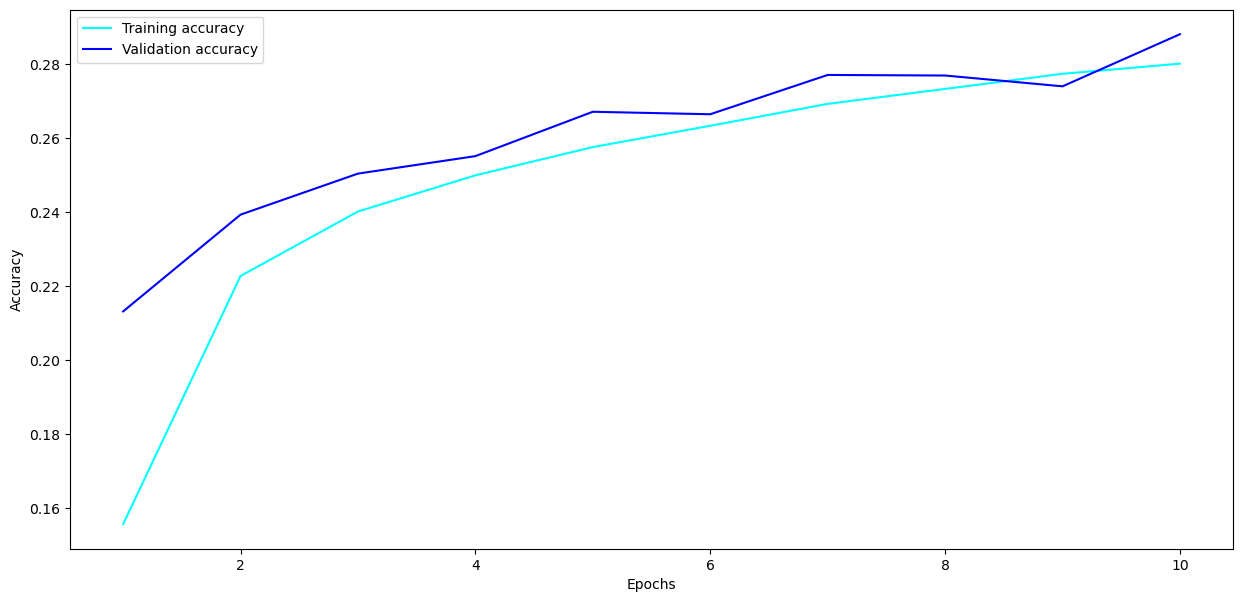

In [22]:
accuracy_array     = history_2.history['accuracy']
val_accuracy_array = history_2.history['val_accuracy']
epochs             = range(1, len(accuracy_array) + 1)
plt.figure(num=1, figsize=(15, 7))
plt.plot(epochs, accuracy_array,     'cyan', label='Training accuracy')
plt.plot(epochs, val_accuracy_array, 'b',  label='Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

___________________![image.png](attachment:b2f19fbc-57fa-40f7-80a1-336642829de1.png)

_______________________![image.png](attachment:39f152ac-8692-403f-a1c4-3a71fe4fd978.png)

n = 29
The Original


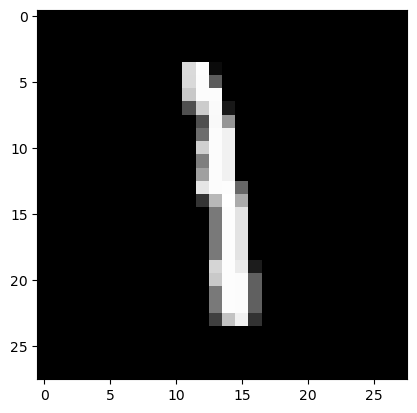

The Noisy Version


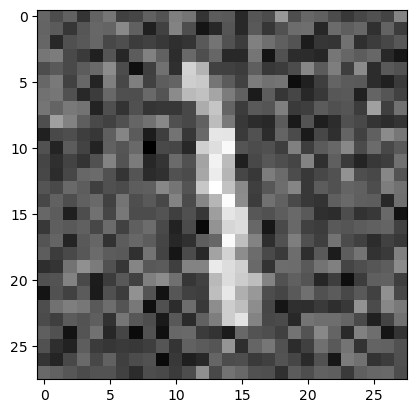

After going through denoiser


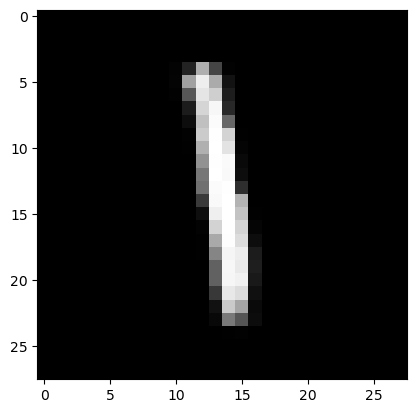

In [23]:
# Generate 100 noisy images
hundred_noisy_images = GaussianNoise(0.2)(x_test[0:100], training=True)

# Denoise
denoised = noise_remover(hundred_noisy_images[0:100])

# Pick random image
n = np.random.randint(0, 100)
print("n =", n)

print("The Original")
plt.imshow(x_test[n], cmap='gray')
plt.show()

print("The Noisy Version")
plt.imshow(hundred_noisy_images[n], cmap='gray')
plt.show()

print("After going through denoiser")
plt.imshow(denoised[n], cmap='gray')
plt.show()

<html> <h3 style="font-style:italic; color:blue;"> AutoEncoders for Denoising Images : </h3> </html>

Use the same digit data set. Add Gaussian noise to it to train an autoencoder that removes noise. Test the noisy samples.


______________________![image.png](attachment:66c883c0-27ea-473a-bfbf-adf60d8af39f.png)

In [ ]:
#GaussianNoise?

___________________![image.png](attachment:daef4479-63f7-4a6a-9927-be13f2230632.png)

In [ ]:
# Plot the original and noisy images

_______________________![image.png](attachment:4013cb09-7c0a-4cc7-b208-31bda1d0f668.png)

____________________![image.png](attachment:2e2bac52-3120-4879-9117-f71bdf1ac965.png)

_____________________![image.png](attachment:003958e0-35f7-4d32-8faf-b9486b5d206f.png)

_________![image.png](attachment:dd745f81-2f9e-4b45-b030-3a4529ea6f1d.png)

______________________![image.png](attachment:cf4f913b-10d4-47b9-9d91-b22fd1c175fa.png)

<html> <h4 style="font-style:italic; color:blue;"> Create a noise removal autoencoder and train it </h4> </html>

- Again similar to above it is a symmetric dense network.
- Gaussian noise is added at the input so that the network sees noisy images and is able to map it to the clean outputs.


### Input - Images with noise
### Labels - Clean images.


In [24]:
# Encoder

encoder = Sequential()
encoder.add(Flatten(input_shape=[28,28]))
encoder.add(GaussianNoise(0.2)) # We are adding noise to make input as noisy images

# Add layers of Encoder network. You could use the same number of layers as you created earlier

#
#
#
#

print(encoder.summary())

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gaussian_noise_6                │ (None, 784)            │             0 │
│ (GaussianNoise)                 │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
# Your OWN Encoder model should be printed here
# Please do not copy the model below

In [25]:
decoder = Sequential()
decoder.add(Dense(50,input_shape=[25],activation='relu'))

# Add layers of the Decoder network. You could use the same number of layers as you created earlier
# Reember - Encoder and Decoder must be symmetric

#
#
#


decoder.add(Dense(28 * 28, activation="sigmoid"))
decoder.add(Reshape([28, 28]))

print(decoder.summary())

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_30 (Dense)                │ (None, 50)             │         1,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 784)            │        39,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_3 (Reshape)             │ (None, 28, 28)         │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41,284 (161.27 KB)

 Trainable params: 41,284 (161.27 KB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
# Your OWN Decoder model should be printed here
# Please do not copy the model below

_________________________![image.png](attachment:b8742807-43dd-41a1-a461-c2a4455e6d07.png)

In [ ]:
# Your code to print the Autoencoder model

#

In [ ]:
# Your OWN Autoencoder model should be printed here

In [ ]:
# Your code to compile the 'noise_remover' model with the same parameters as earlier

# noise_remover.compile( ................  )


<html> <h3 style="font-style:italic; color:red;"> If you are using a personal laptop without a GPU, you should have epochs=10 </h3> </html>

In [ ]:
# Your code to fit 'noise_remover' model with the same parameters as earlier

# history_2 = ..........................


In [ ]:
# Hint: Use (copy and modify) the code from the cells above

___________________![image.png](attachment:05682556-9ec1-46c6-85d5-3db97ba3c04f.png)

___________________________![image.png](attachment:43697532-dcb7-41bf-a1fa-6f630f5d4a29.png)

______________________![image.png](attachment:9dbf1489-73d6-4480-adc7-0ced14e0c9dd.png)

______________________![image.png](attachment:a5bc2008-bc25-45e7-97ba-ae44dffae6ed.png)

_______![image.png](attachment:505ed502-6fd8-4f58-a27f-44a804f20493.png)

<html> <h3 style="font-style:italic; color:blue;"> You can run the previous cell multiple times </h3> </html>  

<html> <h2 style="font-style:bold; color:red;"> Lab Logbook requirements </h2> </html>

 - Put the Encoder, Decoder and Basic Autoencoder models using summary() in your lab logbook.

Ensure that no code or other information is added to the logbook and that only required information is present. Marks will not be awarded if anything else is found in the logbook or instructions are not clearly followed.

NOTE: DON'T FORGET TO SAVE AND BACK UP YOUR COMPLETED JUPYTER NOTEBOOK AND LAB LOGBOOK ON GITHUB.